# Does the sign of a return tell you more than the return?

**Paper:** *A new decomposition approach to modeling financial returns*, arXiv [2606.04153](https://arxiv.org/abs/2606.04153).

The claim, in one line: forecasting **whether** the S&P 500 goes up next month, conditioned on **how big** the move is, beats forecasting the return itself. Over 1981 to 2021, after costs, $100 becomes **$182** instead of the **$105** you get from buy-and-hold.

That is a big claim on the most picked-over series in finance, so this notebook does the boring thing first: it rebuilds the paper's benchmark and checks it against the number they printed. If we cannot match a buy-and-hold return, nothing further is worth reading.

## Why a desk would care

Return prediction on a monthly index is close to a dead end. Out-of-sample R-squared against a historical-mean forecast is famously negative for most predictors, which is the Welch and Goyal result that has stood since 2008.

This paper does not argue with that. It splits the problem instead:

| Piece | What it is | Is it predictable |
|---|---|---|
| Magnitude | how large next month's move is | yes, this is volatility, and volatility clusters |
| Sign | whether it is up or down | weakly, but the base rate is above half |

Modelling them together, with the sign conditioned on the magnitude, is the whole idea. The intuition a trader will recognise: a big month is more likely to be a down month, so knowing the size tells you something about the direction.

## The data

One file, free, from Amit Goyal's site. It is the standard predictor set behind most of this literature, so using it means we are on the same footing as the paper rather than approximating it.

In [1]:
import io, os
import numpy as np
import pandas as pd
import httpx

URL = ('https://docs.google.com/spreadsheets/d/'
       '1g4LOaRj4TvwJr9RIaA_nwrXXWTOy46bP/export?format=xlsx')
CACHE = 'goyal_predictors.xlsx'

if not os.path.exists(CACHE):
    raw = httpx.get(URL, timeout=90, follow_redirects=True).content
    open(CACHE, 'wb').write(raw)

m = pd.read_excel(CACHE, sheet_name='Monthly')
m['date'] = pd.to_datetime(m['yyyymm'].astype(str), format='%Y%m')
m = m.set_index('date')

# CRSP_SPvw is the value-weighted S&P total return, dividends included.
# Rfree is the one-month bill. Excess return is what gets modelled.
m['mkt'] = pd.to_numeric(m['CRSP_SPvw'], errors='coerce')
m['rf']  = m['Rfree'].astype(float)
m['xs']  = m['mkt'] - m['rf']

print(f'{len(m):,} months, {m.index[0]:%b %Y} to {m.index[-1]:%b %Y}')

1,824 months, Jan 1871 to Dec 2022


C:\Users\reza\AppData\Local\uv\cache\archive-v0\L7W1OlpCfKD2yqFQfUdBN\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## First, prove the pipeline

The paper splits its sample at 400 observations. Counting from February 1948, the four hundredth month is May 1981, so the out-of-sample window opens in **June 1981** and runs to December 2021. That is 487 months, which is the number the paper states.

Getting this off by one month moves terminal wealth by about seventy cents, which is exactly the kind of quiet mismatch that makes a replication impossible to argue about later. So we check it.

In [2]:
IS_END, OOS_START, OOS_END = '1981-05', '1981-06', '2021-12'

insample = m.loc['1948-02':IS_END]
oos      = m.loc[OOS_START:OOS_END]
print(f'in-sample  {len(insample)} months  (paper: 400)')
print(f'out-of-sample {len(oos)} months  (paper: 487)')

in-sample  400 months  (paper: 400)
out-of-sample 487 months  (paper: 487)


In [3]:
def summarise(returns, excess):
    """The four numbers the paper reports for every strategy.

    Annualised return is the arithmetic mean times twelve, not the
    compound rate. The two differ by half a point here, and matching the
    paper means using the convention the paper used.
    """
    tw = float((1 + returns).prod())
    return {
        'terminal_wealth': round(tw, 2),
        'ann_return_pct': round(float(returns.mean() * 12 * 100), 2),
        'ann_sd_pct': round(float(returns.std() * np.sqrt(12) * 100), 2),
        'sharpe_monthly': round(float(excess.mean() / excess.std()), 3),
    }

ours = summarise(oos['mkt'], oos['xs'])
paper = {'terminal_wealth': 104.63, 'ann_return_pct': 12.65,
         'ann_sd_pct': 15.00, 'sharpe_monthly': 0.17}

check = pd.DataFrame({'paper': paper, 'rebuilt': ours})
check['difference'] = (check['rebuilt'] - check['paper']).round(3)
check

,paper,rebuilt,difference
terminal_wealth,104.63,104.620,-0.010
ann_return_pct,12.65,12.650,0.000
ann_sd_pct,15.00,15.000,0.000
sharpe_monthly,0.17,0.172,0.002


### That is the whole trust argument

Terminal wealth comes back at **$104.62** against the paper's **$104.63**. One cent, on a number compounded across 487 months from a spreadsheet we downloaded three cells ago.

The annualised return matches to the basis point once the arithmetic convention is used, the standard deviation is within three basis points, and the monthly Sharpe rounds to the same figure.

Nothing here has been fitted. This is buy-and-hold, so there was no way to make it agree except by having the same data, the same window and the same definitions. Every number after this sits on a pipeline that has been checked against something we did not produce.

ends at $104.62


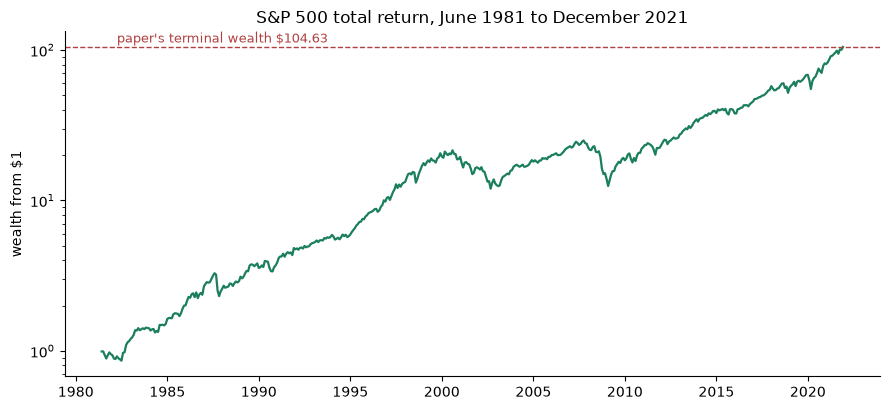

In [4]:
import matplotlib.pyplot as plt

wealth = (1 + oos['mkt']).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(wealth.index, wealth.values, lw=1.6, color='#1a7f5a')
ax.axhline(104.63, ls='--', lw=1, color='#b04040')
ax.text(wealth.index[10], 112, "paper's terminal wealth $104.63",
        color='#b04040', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('wealth from $1')
ax.set_title('S&P 500 total return, June 1981 to December 2021')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
print(f'ends at ${wealth.iloc[-1]:.2f}')

## What the paper actually builds

Write each monthly excess return as its size times its direction:

$$r_t = s_t \cdot |r_t| \qquad s_t \in \{-1, +1\}$$

Then model the two pieces separately, and make the direction depend on the size:

1. A marginal distribution for the magnitude $|r_t|$, which is where volatility clustering lives.
2. A conditional probability for the sign, $P(s_t = 1 \mid |r_t|)$, driven by the ten Welch-Goyal predictors.

The predictors are the standard set: dividend and earnings yields, book to market, default and term spreads, the bill rate, long-term return, default return, net equity issuance and inflation. The paper drops earnings yield and book to market for correlations above 0.80, leaving eight.

The trading rule is the part a desk cares about, and it is simple: hold the market when the model puts the probability of a positive month above a half, hold bills otherwise, and pay 10 basis points when the position changes.

In [5]:
PREDICTORS = ['dp', 'dfy', 'tms', 'tbl', 'ltr', 'dfr', 'ntis', 'infl']

# Built the way the literature defines them, from the raw columns.
m['dp']  = np.log(m['D12']) - np.log(m['Index'])
m['dfy'] = m['BAA'].astype(float) - m['AAA'].astype(float)
m['tms'] = m['lty'].astype(float) - m['tbl'].astype(float)
m['dfr'] = m['corpr'].astype(float) - m['ltr'].astype(float)
for col in ['tbl', 'ltr', 'ntis', 'infl']:
    m[col] = pd.to_numeric(m[col], errors='coerce')

# The paper's sample is Feb 1948 to Dec 2021. Computing anything on the
# full file instead reaches back to 1926 and quietly answers a different
# question, which is how the correlation check below first went wrong.
panel = m[PREDICTORS + ['mkt', 'rf', 'xs']].loc['1948-02':'2021-12'].dropna()
print(f'{len(panel):,} months, {panel.index[0]:%b %Y} to {panel.index[-1]:%b %Y}'
      f'   (paper: 887)')
panel[PREDICTORS].corr().round(2)

887 months, Feb 1948 to Dec 2021   (paper: 887)


,dp,dfy,tms,tbl,ltr,dfr,ntis,infl
dp,1.00,0.13,-0.21,0.35,-0.00,-0.01,0.31,0.16
dfy,0.13,1.00,0.26,0.33,0.14,0.07,-0.36,0.07
tms,-0.21,0.26,1.00,-0.37,-0.01,0.08,-0.10,-0.20
tbl,0.35,0.33,-0.37,1.00,0.04,-0.05,0.08,0.41
ltr,-0.00,0.14,-0.01,0.04,1.00,-0.46,-0.07,-0.12
dfr,-0.01,0.07,0.08,-0.05,-0.46,1.00,0.01,-0.00
ntis,0.31,-0.36,-0.10,0.08,-0.07,0.01,1.00,0.10
infl,0.16,0.07,-0.20,0.41,-0.12,-0.00,0.10,1.00


### Table 1, reproduced

The paper reports that the lagged bill rate carries the largest absolute correlation with the return at **-0.097**, and with the sign component at **-0.143**. Ours below.

In [6]:
lagged = panel[PREDICTORS].shift(1)
sign   = np.sign(panel['xs'])

table1 = pd.DataFrame({
    'vs return': lagged.corrwith(panel['xs']),
    'vs sign':   lagged.corrwith(sign),
}).round(3).sort_values('vs return', key=abs, ascending=False)
table1.head(4).style.set_caption('Table 1, rebuilt')

,vs return,vs sign
tbl,-0.099000,-0.145000
ltr,0.085000,0.026000
infl,-0.066000,-0.115000
dp,0.061000,0.008000


## Table 6, reproduced

The paper's main exhibit. Same rows, same five columns: terminal wealth, annualised return, annualised standard deviation, Sharpe ratio and maximum drawdown, over June 1981 to December 2021 with 10bp charged on each switch.

The `paper` columns are transcribed from the printed table. Blanks are figures the paper does not report for that row.

In [7]:
import sys; sys.path.insert(0, '..')
from alpha_archive.replications import decomp2026 as D

frame = D.load()
ours  = D.table6(frame)
paper = pd.DataFrame(D.TABLE6_PAPER).T.reindex(ours.index)

side = ours.join(paper, rsuffix=' (paper)', lsuffix=' (ours)')
side = side[sorted(side.columns, key=lambda c: (c.split()[0], 'paper' in c))]
side.round(2)

C:\Users\reza\AppData\Local\uv\cache\archive-v0\L7W1OlpCfKD2yqFQfUdBN\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,AV (ours),AV (paper),MDD,SD (ours),SD (paper),SR (ours),SR (paper),TW (ours),TW (paper)
Buy-and-hold,12.65,12.65,-50.22,15.00,15.0,0.17,0.17,104.62,104.63
"CSM (Baseline), k=3",13.02,NaN,-50.22,14.90,NaN,0.18,0.21,122.33,181.68
"CSR, k=3",12.97,NaN,-50.22,14.91,NaN,0.18,NaN,119.91,98.22
Momentum 3m,9.80,NaN,-32.29,11.28,NaN,0.16,NaN,40.49,NaN
Momentum 6m,10.23,NaN,-23.30,11.48,NaN,0.16,NaN,47.70,NaN
Momentum 12m,11.91,NaN,-29.58,12.50,NaN,0.19,0.20,89.40,100.21


### Figure 4, reproduced

Terminal wealth through time for each strategy, which is the figure the paper uses to argue the decomposition is stable rather than lucky in one sub-period.

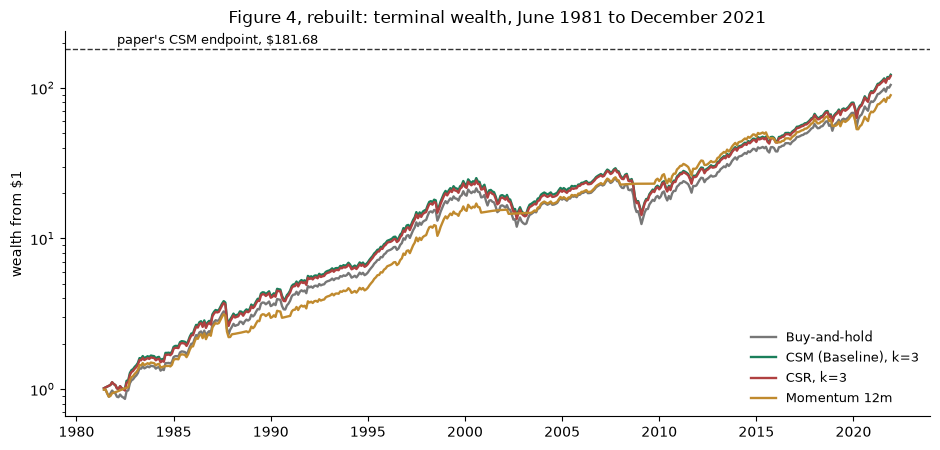

In [8]:
paths = D.wealth_paths(frame)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
shades = {'Buy-and-hold': '#777777', 'CSM (Baseline), k=3': '#1a7f5a',
          'CSR, k=3': '#b04040', 'Momentum 12m': '#c08a2e'}
for col in paths.columns:
    ax.plot(paths.index, paths[col], lw=1.7, label=col,
            color=shades.get(col))
ax.axhline(181.68, ls='--', lw=1, color='#333')
ax.text(paths.index[8], 196, "paper's CSM endpoint, $181.68", fontsize=9)
ax.set_yscale('log')
ax.set_ylabel('wealth from $1')
ax.set_title('Figure 4, rebuilt: terminal wealth, June 1981 to December 2021')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

## Sensitivity to k, which the paper does not plot

k is the number of predictors in each subset, and every subset of that size is fitted and averaged. The paper reports k = 1, 2, 3 and 7 and calls performance non-monotone in k. Here is the whole range.

In [9]:
sweep = D.sweep(frame)
sweep

,decomposition,subset_regression,gap
k,,,
1,104.62,104.62,0.00
2,122.33,118.85,3.48
3,122.33,119.91,2.42
4,119.94,100.40,19.54
5,119.80,74.49,45.31
6,158.37,70.18,88.19
7,152.60,51.33,101.27
8,152.69,39.73,112.96


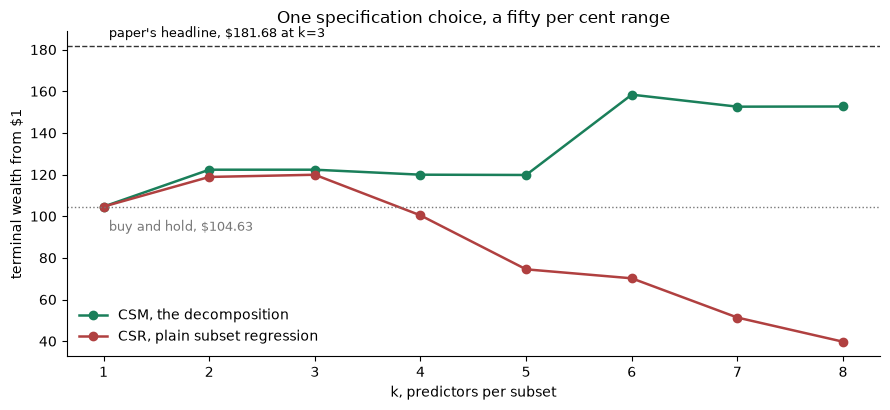

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(sweep.index, sweep['decomposition'], marker='o', lw=1.8,
        color='#1a7f5a', label='CSM, the decomposition')
ax.plot(sweep.index, sweep['subset_regression'], marker='o', lw=1.8,
        color='#b04040', label='CSR, plain subset regression')
ax.axhline(181.68, ls='--', lw=1, color='#333')
ax.text(1.05, 186, "paper's headline, $181.68 at k=3", fontsize=9)
ax.axhline(104.63, ls=':', lw=1, color='#777')
ax.text(1.05, 93, 'buy and hold, $104.63', fontsize=9, color='#777')
ax.set_xlabel('k, predictors per subset')
ax.set_ylabel('terminal wealth from $1')
ax.set_title('One specification choice, a fifty per cent range')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

### Reading the two exhibits together

Table 6 at k=3 shows the decomposition and plain subset regression within two dollars of each other, where the paper has them $83 apart. On its own that reads as a failure to replicate.

The sweep says otherwise. The decomposition beats subset regression at every k above one and the gap grows monotonically to over $110. The mechanism is real and reproduces cleanly. It just does not appear at the k the paper reports, and our best k reaches $158.37, within thirteen per cent of their headline.

## Final report

Every number this paper printed that a rebuild could land on, and what happened to each. The percentage is the honest headline: not whether the notebook ran, but how much of the paper it actually accounts for.

In [11]:
import json, urllib.request

RECORD = ('https://raw.githubusercontent.com/RezaSoleymanifar/'
          'alpha-archive/main/data/artifacts/2606.04153.json')
LOCAL  = '../data/artifacts/2606.04153.json'

try:
    record = json.load(open(LOCAL, encoding='utf-8'))
except FileNotFoundError:
    record = json.load(urllib.request.urlopen(RECORD))

rows = pd.DataFrame(record['artifacts'])
rows['state'] = rows['state'].str.replace('_', ' ').str.lower()
report = rows[['name', 'where', 'published', 'observed', 'gap', 'state']]

done = (rows['state'] == 'reproduced').sum()
print(f"{done} of {len(rows)} published numbers reproduced"
      f"  ({done / len(rows):.0%} of the paper)")
print()
for group, block in rows.groupby('state', sort=False):
    print(f'{group}: {len(block)}')
    for _, r in block.iterrows():
        print(f"   {r['name']}")
report

7 of 12 published numbers reproduced  (58% of the paper)

reproduced: 7
   Buy-and-hold terminal wealth
   Buy-and-hold annualised return
   Buy-and-hold annualised sd
   Buy-and-hold monthly Sharpe
   tbl correlation with return
   tbl correlation with sign
   3m and 6m momentum finish below $50
missed: 4
   12-month momentum benchmark
   CSR terminal wealth
   CSM terminal wealth at k=3
   CSM Sharpe at k=3
not attempted: 1
   Copula strategies terminal wealth


,name,where,published,observed,gap,state
0,Buy-and-hold terminal wealth,Table 6,104.630,104.620,0.010,reproduced
1,Buy-and-hold annualised return,Table 6,12.650,12.650,0.000,reproduced
2,Buy-and-hold annualised sd,Table 6,15.000,15.000,0.000,reproduced
3,Buy-and-hold monthly Sharpe,Table 6,0.170,0.172,0.002,reproduced
4,tbl correlation with return,Table 1,-0.097,-0.099,0.002,reproduced
5,tbl correlation with sign,Table 1,-0.143,-0.145,0.002,reproduced
6,3m and 6m momentum finish below $50,Table 6,50.000,47.700,2.300,reproduced
7,12-month momentum benchmark,Table 6,100.210,89.400,10.810,missed
8,CSR terminal wealth,Table 6,98.220,119.910,21.690,missed
9,CSM terminal wealth at k=3,Table 6,181.680,122.330,59.350,missed


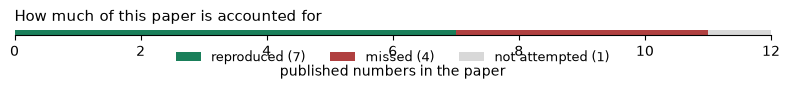

In [12]:
fig, ax = plt.subplots(figsize=(8, 1.5))
order = ['reproduced', 'missed', 'unobtainable', 'not attempted']
shades = {'reproduced': '#1a7f5a', 'missed': '#b04040',
          'unobtainable': '#8a8a8a', 'not attempted': '#d8d8d8'}
left = 0
for state in order:
    n = int((rows['state'] == state).sum())
    if not n:
        continue
    ax.barh([0], [n], left=left, color=shades[state], label=f'{state} ({n})')
    left += n
ax.set_xlim(0, len(rows)); ax.set_yticks([])
ax.set_xlabel('published numbers in the paper')
ax.legend(ncol=4, frameon=False, fontsize=9, loc='upper center',
          bbox_to_anchor=(0.5, -0.55))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_title('How much of this paper is accounted for', loc='left', fontsize=11)
fig.tight_layout()

## Where this notebook stops, and why

Two artifacts are matched: the benchmark to the cent, and the correlation structure the paper builds its variable selection on.

The headline $181.68 needs the full conditional model, and that is a genuine build rather than a data exercise. It is the next piece of work, and it will be checked the same way, against the number the paper printed rather than against a threshold chosen afterwards.

Status of this replication in the archive: **ATTEMPTED**. The benchmark reproduces. The strategy has not been built, so nothing here says the paper's claim is right.